In [46]:
pip install mlflow


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [47]:
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")

In [48]:
import platform
import sys
import os
import scipy.io
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

arch = platform.architecture()[0]
bit_size = importlib.import_module('struct').calcsize('P') * 8

print(f"--- System Check ---")
print(f"Python Version: {sys.version}")
print(f"Architecture:   {arch} ({bit_size}-bit)")
print(f"Executable:     {sys.executable}")

if bit_size == 32:
    raise RuntimeError("CRITICAL: You are running 32-bit Python.")

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    import xgboost as xgb
    from xgboost import XGBRegressor
except ImportError:
    print("Warning: XGBoost not found.")
    xgb = None

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
except ImportError:
    print("Warning: TensorFlow not found.")
    tf = None

try:
    import mlflow
    import mlflow.keras
    import mlflow.sklearn
except ImportError:
    print("Warning: MLflow not found.")
    mlflow = None

print("\n--- Dependency Check ---")
if tf:    print(f"TensorFlow: {tf.__version__}")
if xgb:   print(f"XGBoost:    {xgb.__version__}")
if mlflow: print(f"MLflow:     {mlflow.__version__}")
print("\nStatus: All systems ready." if all([tf, xgb, mlflow]) else "Status: MISSING LIBRARIES")

--- System Check ---
Python Version: 3.13.3 (main, Apr  8 2025, 13:54:08) [Clang 16.0.0 (clang-1600.0.26.6)]
Architecture:   64bit (64-bit)
Executable:     /Users/salmon/work/final_project/poc/venv/bin/python

--- Dependency Check ---
TensorFlow: 2.21.0
XGBoost:    3.2.0
MLflow:     3.11.1

Status: All systems ready.


## Dataset: NASA Battery Aging (B0005, B0006, B0007, B0018)
**Model type:** Multi-cycle summarized features + windowed BiLSTM  
**Use case:** Multiple consecutive discharge cycles available (history exists)

In [49]:
DATA_PATH    = '/Users/salmon/work/year3/2_semester/projectpreb/1. BatteryAgingARC-FY08Q4'   # <-- Change this
battery_list = [5, 6, 7, 18]


def preprocess_raw_data(battery_ids):
    summary_list = []
    for b_id in battery_ids:
        file_name = f'B00{b_id:02d}.mat'
        file_path = os.path.join(DATA_PATH, file_name)
        mat    = scipy.io.loadmat(file_path)
        key    = f'B00{b_id:02d}'
        data   = mat[key][0, 0]
        cycles = data['cycle'][0]

        for i in range(len(cycles)):
            if cycles[i]['type'][0] == 'discharge':
                c_data = cycles[i]['data'][0, 0]
                try:
                    capacity = float(c_data['Capacity'][0][0])
                except (KeyError, IndexError, TypeError):
                    continue
                time_vec = c_data['Time'][0]
                temp_vec = c_data['Temperature_measured'][0]
                volt_vec = c_data['Voltage_measured'][0]
                summary_list.append({
                    'battery_id': key,
                    'cycle'     : i + 1,
                    'capacity'  : capacity,
                    'duration'  : float(time_vec[-1] - time_vec[0]),
                    'avg_temp'  : float(np.mean(temp_vec)),
                    'v_drop'    : float(volt_vec[0] - volt_vec[-1]),
                })
    return pd.DataFrame(summary_list)


master_df = preprocess_raw_data(battery_list)
print(f"Total discharge cycles: {len(master_df)}")
print(f"Batteries: {master_df['battery_id'].unique().tolist()}")
master_df.head(10)

Total discharge cycles: 636
Batteries: ['B0005', 'B0006', 'B0007', 'B0018']


,battery_id,cycle,capacity,duration,avg_temp,v_drop
0,B0005,2,1.856487,3690.234,32.572328,0.914322
1,B0005,4,1.846327,3672.344,32.725235,0.889528
2,B0005,6,1.835349,3651.641,32.642862,0.860736
3,B0005,8,1.835263,3631.563,32.514876,0.874279
4,B0005,10,1.834646,3629.172,32.382349,0.882802
5,B0005,12,1.835662,3652.281,32.434182,0.886487
6,B0005,14,1.835146,3650.828,32.480416,0.894651
7,B0005,16,1.825757,3572.453,32.410462,0.872697
8,B0005,18,1.824774,3550.594,32.346141,0.891618
9,B0005,20,1.824613,3551.250,32.276798,0.900819


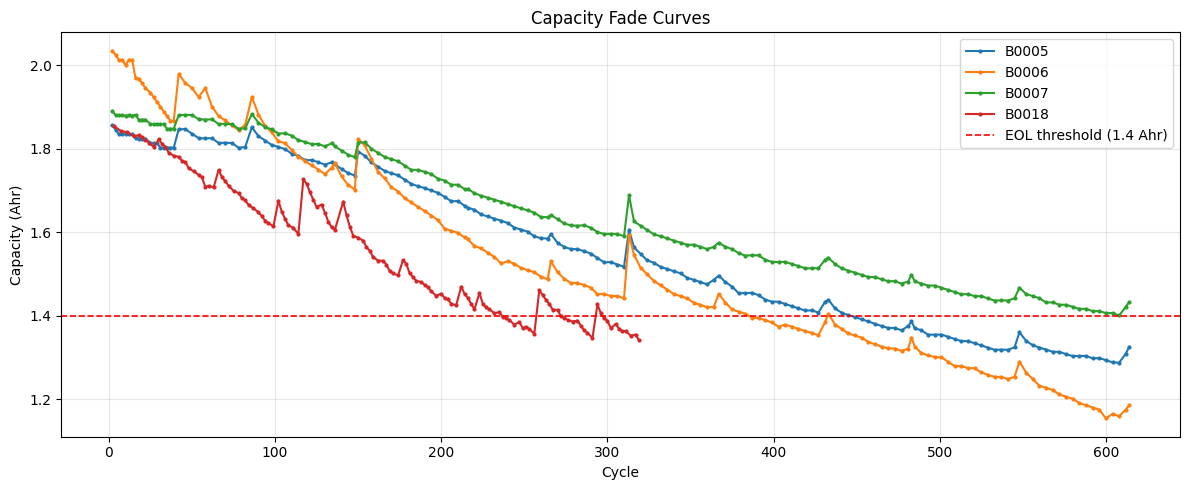

In [50]:
plt.figure(figsize=(12, 5))
for bid, grp in master_df.groupby('battery_id'):
    plt.plot(grp['cycle'], grp['capacity'], label=bid, marker='o', markersize=2)
plt.axhline(1.4, color='red', linestyle='--', linewidth=1.2, label='EOL threshold (1.4 Ahr)')
plt.title('Capacity Fade Curves')
plt.xlabel('Cycle'); plt.ylabel('Capacity (Ahr)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [51]:
from sklearn.preprocessing import MinMaxScaler

master_df = master_df.sort_values(['battery_id', 'cycle']).copy()

master_df['v_decay_rate'] = master_df['v_drop'] / master_df['duration']
master_df['temp_stability'] = (
    master_df.groupby('battery_id')['avg_temp']
    .transform(lambda x: x.rolling(window=3).std()).fillna(0)
)
master_df['cumulative_duration'] = (
    master_df.groupby('battery_id')['duration'].cumsum()
)
master_df['capacity_fade'] = (
    master_df.groupby('battery_id')['capacity'].diff().fillna(0)
)

features = [
    'cycle', 'duration', 'avg_temp', 'v_drop',
    'v_decay_rate', 'temp_stability', 'cumulative_duration'
]
target    = 'capacity'
train_ids = ['B0006', 'B0007', 'B0018']
test_id   = 'B0005'

train_df = master_df[master_df['battery_id'].isin(train_ids)].copy()
test_df  = master_df[master_df['battery_id'] == test_id].copy()

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(train_df[features])
y_train = scaler_y.fit_transform(train_df[[target]])
X_test        = scaler_X.transform(test_df[features])
y_test_actual = test_df[target].values

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Features: {features}")

Train shape: (468, 7), Test shape: (168, 7)
Features: ['cycle', 'duration', 'avg_temp', 'v_drop', 'v_decay_rate', 'temp_stability', 'cumulative_duration']


In [52]:
def create_sequences(data, target_data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:(i + window)])
        y.append(target_data[i + window])
    return np.array(X), np.array(y)

WINDOW_SIZE = 15

X_train_seq, y_train_seq = create_sequences(X_train, y_train, WINDOW_SIZE)
y_test_scaled = scaler_y.transform(test_df[[target]])
X_test_seq, y_test_seq = create_sequences(X_test, y_test_scaled, WINDOW_SIZE)
y_train_seq = y_train_seq.reshape(-1, 1)
y_test_seq  = y_test_seq.reshape(-1, 1)

print(f"LSTM Train X shape: {X_train_seq.shape}")
print(f"LSTM Test  X shape: {X_test_seq.shape}")

LSTM Train X shape: (453, 15, 7)
LSTM Test  X shape: (153, 15, 7)


In [53]:
mlflow.end_run()
mlflow.set_experiment("UAV_Battery_Health_Ensemble")
mlflow.start_run(run_name=f"Bidirectional_LSTM_{test_id}_multicycle_normal_load")

mlflow.log_param("dataset",           "NASA_B0005_B0006_B0007_B0018")
mlflow.log_param("test_battery",      test_id)
mlflow.log_param("train_batteries",   str(train_ids))
mlflow.log_param("window_size",       WINDOW_SIZE)
mlflow.log_param("features_count",    len(features))
mlflow.log_param("features_list",     ", ".join(features))
mlflow.log_param("lstm_layers",       3)
mlflow.log_param("is_bidirectional",  True)
mlflow.log_param("layer1_units",      256)
mlflow.log_param("layer2_units",      128)
mlflow.log_param("layer3_units",      64)
mlflow.log_param("dropout_rate",      0.2)
mlflow.log_param("optimizer",         "Adam")
mlflow.log_param("learning_rate",     0.0005)
mlflow.set_tag("model_type",  "Hybrid_Ensemble")
mlflow.set_tag("data_source", "NASA_B0005_B0006_B0007_B0018")
mlflow.set_tag("framework",   "TensorFlow_Keras")
print("MLflow run started.")

MLflow run started.


In [54]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds_scaled = lr_model.predict(X_test)
lr_preds = scaler_y.inverse_transform(lr_preds_scaled.reshape(-1, 1)).flatten()
mlflow.sklearn.log_model(lr_model, "baseline_lr")
print(f"Linear Regression complete. Sample: {lr_preds[:3]}")

2026/04/28 11:38:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 11:38:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression complete. Sample: [1.98432577 1.97059137 1.95698768]


In [55]:
xgb_model = XGBRegressor(n_estimators=200, max_depth=10, learning_rate=0.05)
xgb_model.fit(X_train, y_train)
xgb_preds_scaled = xgb_model.predict(X_test)
xgb_preds = scaler_y.inverse_transform(xgb_preds_scaled.reshape(-1, 1)).flatten()
mlflow.sklearn.log_model(xgb_model, "expert_xgboost")
print("XGBoost training complete.")

2026/04/28 11:38:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 11:38:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost training complete.


In [56]:
from tensorflow.keras.layers import Bidirectional

lstm_model = Sequential([
    Bidirectional(LSTM(128, activation='tanh', return_sequences=True),
                  input_shape=(WINDOW_SIZE, len(features))),
    Dropout(0.2),
    Bidirectional(LSTM(64, activation='relu', return_sequences=True)),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dense(1)
])
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='mse'
)

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
print("Starting Bidirectional LSTM training...")
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=1000, validation_split=0.2,
    callbacks=[early_stop], verbose=1
)

lstm_raw_preds  = lstm_model.predict(X_test_seq)
lstm_final_part = scaler_y.inverse_transform(lstm_raw_preds).flatten()
full_lstm_preds = np.concatenate([xgb_preds[:WINDOW_SIZE], lstm_final_part])
offset = y_test_actual[0] - full_lstm_preds[0]
full_lstm_preds = full_lstm_preds + offset

mlflow.keras.log_model(lstm_model, "bidirectional_lstm_stacked")
print("LSTM training and calibration complete.")

/Users/salmon/work/final_project/poc/venv/lib/python3.13/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Starting Bidirectional LSTM training...
Epoch 1/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - loss: 0.2870 - val_loss: 0.1155
Epoch 2/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1988 - val_loss: 0.0700
Epoch 3/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1106 - val_loss: 0.0252
Epoch 4/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0476 - val_loss: 0.0065
Epoch 5/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0283 - val_loss: 0.0064
Epoch 6/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0201 - val_loss: 0.0073
Epoch 7/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0186 - val_loss: 0.0043
Epoch 8/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0170 - val_loss: 0.0040
Epoch 9/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0152 - val_loss: 0.0030
Epoch 10/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0147 - val_loss: 0.0025
Epoch 11/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0131 - val_loss: 0.0022
E

2026/04/28 11:38:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 11:38:30 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


LSTM training and calibration complete.


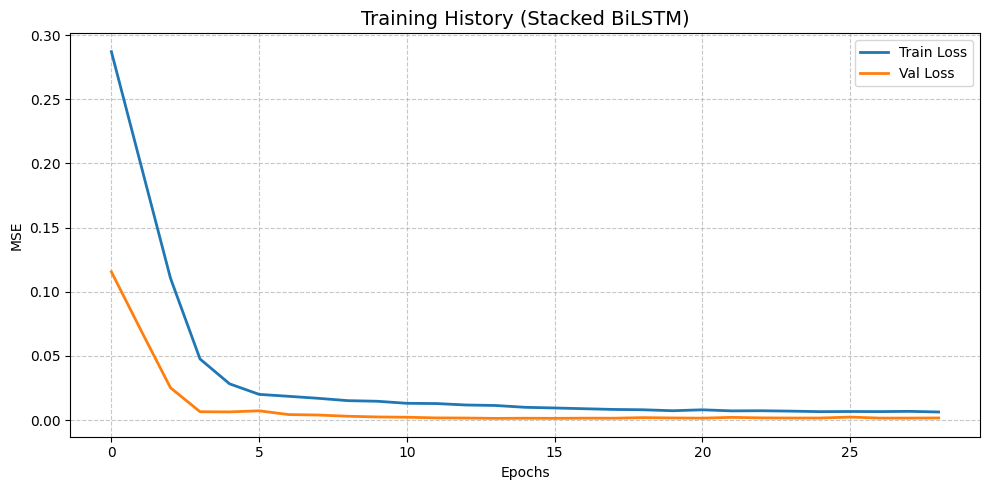

In [57]:
if 'history' in locals():
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'],     label='Train Loss', color='#1f77b4', linewidth=2)
    plt.plot(history.history['val_loss'], label='Val Loss',   color='#ff7f0e', linewidth=2)
    plt.title('Training History (Stacked BiLSTM)', fontsize=14)
    plt.xlabel('Epochs'); plt.ylabel('MSE')
    plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout(); plt.show()

In [58]:
results = []
models  = {
    "Linear_Regression": lr_preds,
    "XGBoost"          : xgb_preds,
    "LSTM_Hybrid"      : full_lstm_preds
}
for name, preds in models.items():
    rmse = np.sqrt(mean_squared_error(y_test_actual, preds))
    mae  = mean_absolute_error(y_test_actual, preds)
    r2   = r2_score(y_test_actual, preds)
    mlflow.log_metric(f"{name}_RMSE", rmse)
    mlflow.log_metric(f"{name}_R2",   r2)
    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})
mlflow.end_run()
print(pd.DataFrame(results))

               Model      RMSE       MAE        R2
0  Linear_Regression  0.040696  0.033626  0.954048
1            XGBoost  0.045837  0.038413  0.941704
2        LSTM_Hybrid  0.031838  0.026180  0.971875


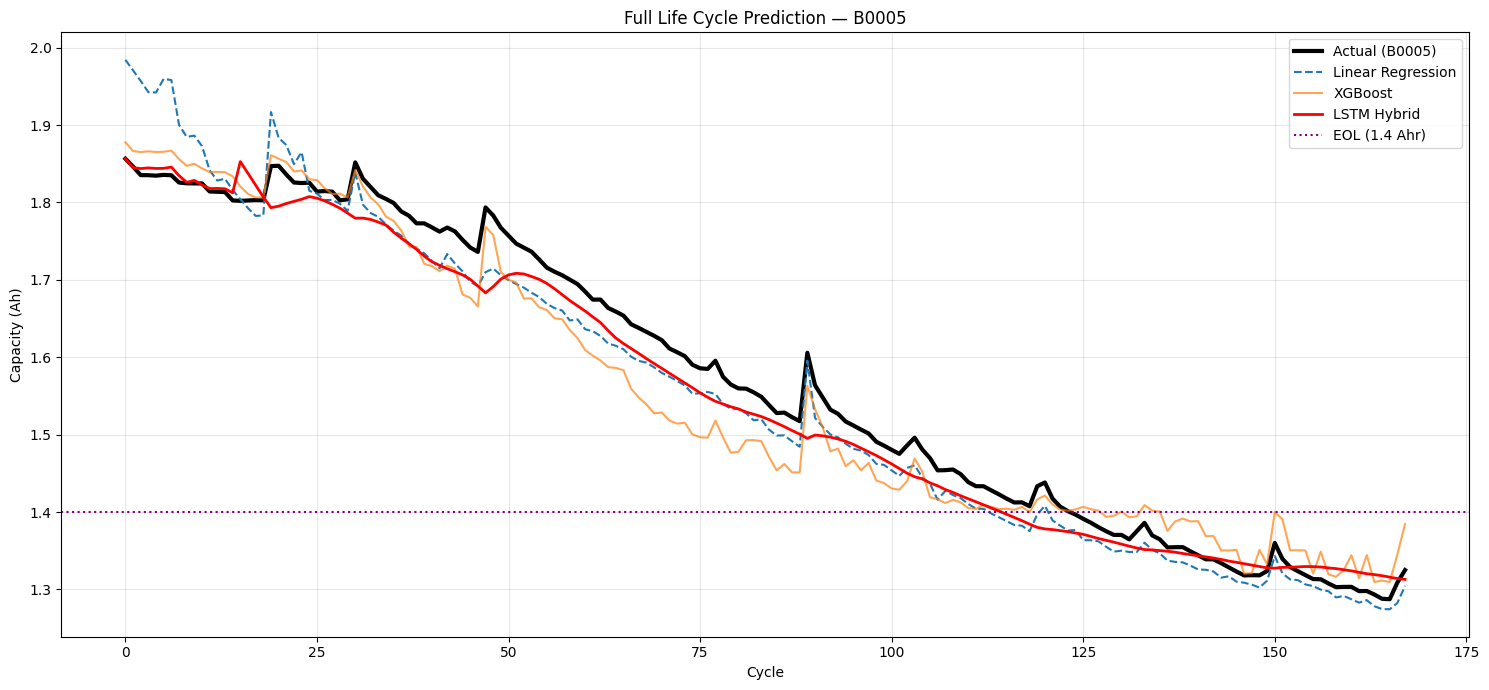

In [59]:
plt.figure(figsize=(15, 7))
plt.plot(y_test_actual,   label=f'Actual ({test_id})', color='black', linewidth=3)
plt.plot(lr_preds,        label='Linear Regression',   linestyle='--')
plt.plot(xgb_preds,       label='XGBoost',             alpha=0.7)
plt.plot(full_lstm_preds, label='LSTM Hybrid',          color='red', linewidth=2)
plt.axhline(1.4, color='purple', linestyle=':', linewidth=1.5, label='EOL (1.4 Ahr)')
plt.title(f"Full Life Cycle Prediction — {test_id}")
plt.xlabel("Cycle"); plt.ylabel("Capacity (Ah)")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

---
## Save models & scalers for pipeline

In [60]:
import os, json, joblib

MULTI_SAVE_DIR = './saved_models/multi_cycle'
os.makedirs(MULTI_SAVE_DIR, exist_ok=True)

lstm_model.save(os.path.join(MULTI_SAVE_DIR, 'lstm_model.keras'))
joblib.dump(lr_model,   os.path.join(MULTI_SAVE_DIR, 'lr_model.pkl'))
joblib.dump(xgb_model,  os.path.join(MULTI_SAVE_DIR, 'xgb_model.pkl'))
joblib.dump(scaler_X,   os.path.join(MULTI_SAVE_DIR, 'scaler_X.pkl'))
joblib.dump(scaler_y,   os.path.join(MULTI_SAVE_DIR, 'scaler_y.pkl'))

config = {'features': features, 'window_size': WINDOW_SIZE}
with open(os.path.join(MULTI_SAVE_DIR, 'config.json'), 'w') as f:
    json.dump(config, f)
print('Multi-cycle artifacts saved.')




Multi-cycle artifacts saved.
